# Ablation C: GNN Architecture Comparison

This ablation compares the main **GAT model** with other GNN architectures such as **GCN, GIN, GINE, and GraphSAGE**. The goal is to understand whether the model improves because of:

1. **edge features** such as cosine similarity,  
2. the **attention mechanism** in GAT,  
3. or both.

| Variant | Conv layer | Edge info | Attention | Role |
|---------|-----------|-----------|-----------|------|
| **GAT (+edge)** | `GATConv (edge_dim=1)` | ✓ cosine | ✓ | our model |
| GAT (−edge) | `GATConv` | ✗ | ✓ | isolate the edge-feature contribution |
| GCN (−edge) | `GCNConv` | ✗ | ✗ | no-edge baseline |
| GCN (+edge) | `GCNConv (edge_weight)` | ✓ cosine | ✗ | GCN with edge info |
| GINE (+edge) | `GINEConv (edge_dim=1)` | ✓ cosine | ✗ |  GIN with edge info |
| GIN (−edge) | `GINConv` | ✗ | ✗ | no-edge baseline |
| GraphSAGE (−edge) | `SAGEConv` | ✗ (unsupported) | ✗ | no-edge baseline |

### How to Read the Results

- **GAT (+ edge) vs GAT (− edge)** shows the effect of edge features.
- **GAT (− edge) vs GCN/GIN/GraphSAGE (− edge)** shows the effect of attention without edge features.
- **GAT (+ edge) vs GCN (+ edge) / GINE (+ edge)** shows whether GAT is better when other models also use edge information.

All models use the same graph, node features, split, training setup, optimizer, and hyperparameters. Only the GNN architecture and use of edge features are changed. Every architecture is trained under 3 fixed seeds (`seeds` in the config cell) and results are reported as mean +/- std, rather than a single noisy run per variant.


## 1. Imports

Standard data/graph/training stack, plus all five PyTorch Geometric conv layers used by
the architecture variants below (`GATConv`, `GCNConv`, `GINConv`, `GINEConv`,
`SAGEConv`).

In [1]:
from torch_geometric.nn import GATConv, GCNConv, GINConv, GINEConv, SAGEConv
import os, csv, gc
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.sparse.csgraph import minimum_spanning_tree as _mst_func
from scipy.sparse import csr_matrix as _csr_mat
import torch
import torch.nn as nn
from torch_geometric.utils import dropout_edge
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'networkx  : {nx.__version__}')
print(f'igraph    : {ig.__version__}')
print(f'leidenalg : {leidenalg.version}')
print(f'device    : {device}')

C:\Users\bibhushaojha\AppData\Local\anaconda3\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


networkx  : 3.4.2
igraph    : 1.0.0
leidenalg : 0.12.0
device    : cuda


## 2. Configuration

Paths, the 4-class filter, the shared GNN hyperparameters (all architectures use the same
`hidden` / `num_layers` / `dropout` / `lr` / etc. — only the encoder block differs), and
`seeds`, the list of random seeds each architecture is trained on in the sweep below
(`[42, 123, 2024]` — three runs per architecture so results are mean +/- std, not a single
noisy run).

In [2]:
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
mgf_path          = 'NIST/NIST_GC_EI_MAX_LIBRARY.mgf'
nist_classes_path = 'NIST/nist_classes.csv'
nist_dir          = 'C:/Users/bibhushaojha/Desktop/graph-based-spectral-classifier/NIST'
masst_tsv_path    = f'{nist_dir}/results_t50_e20.tsv'

use_4class = True
four_classes = [
    'Benzene and substituted derivatives',
    'Carboxylic acids and derivatives',
    'Fatty Acyls',
    'Organooxygen compounds',
]
random_state = 42; test_size = 0.20; val_size = 0.10
leiden_seed = 42; min_leiden_size = 10

# Shared GNN hyperparameters
hidden      = 128
num_layers  = 2
num_heads   = 4   # used by GAT only
dropout     = 0.3
drop_edge_p = 0.1
epochs      = 200
lr          = 1e-3
patience    = 20
w_sc        = 0.3
w_cl        = 0.7

# Multiple random seeds per architecture -> mean +/- std instead of a single noisy run.
# (torch.manual_seed is otherwise never set in this notebook, so weight init, dropout,
# and DropEdge draws would be uncontrolled between architectures without this.)
seeds = [42, 123, 2024]


## 3–7. Data, Split, Features, MCN (transductive, reused from hierarchical notebook)

Same transductive pipeline as `spectral_classifier-hierarchical.ipynb`: the molecular
network is built over **all** nodes (train + val + test) purely from spectral similarity
(labels never touched). Community detection + per-community Maximum Weight Spanning Tree
run over all nodes, community features are computed for all nodes, and the **same** graph
is used for training and evaluation with the loss masked to training nodes — leakage-free
transductive learning.

In [3]:
def parse_mgf_file(path):
    entries, inside, meta, peaks = [], False, {}, []
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for raw in f:
            line = raw.strip()
            if not line: continue
            if line == 'BEGIN IONS':  inside, meta, peaks = True, {}, []; continue
            if line == 'END IONS':
                if inside: entries.append({'meta': meta.copy(),
                    'peaks': np.array(peaks, dtype=float) if peaks else np.empty((0,2), dtype=float)})
                inside, meta, peaks = False, {}, []; continue
            if not inside: continue
            if '=' in line: k, v = line.split('=',1); meta[k.strip()] = v.strip(); continue
            parts = line.split()
            if len(parts) >= 2:
                try: peaks.append([float(parts[0]), float(parts[1])])
                except ValueError: pass
    return entries

def read_nist_classes_csv(path):
    label_map = {}
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for row in csv.DictReader(f):
            sid = int(row['file'].strip()); sk = row['Superklass'].strip(); k = row['klass'].strip()
            label_map[sid] = {'superclass': None if sk == 'null' else sk,
                              'klass': None if (k == 'null' or k.startswith('subklass:')) else k}
    return label_map

def peaks_to_features(peaks, top_k=20):
    n_out = top_k * 17
    if peaks is None or len(peaks) == 0: return np.zeros(n_out, dtype=np.float32)
    p = peaks.astype(np.float32); p = p[np.argsort(p[:,1])[::-1][:top_k]]
    if len(p) < top_k: p = np.vstack([p, np.zeros((top_k-len(p),2), dtype=np.float32)])
    mz, inten = p[:,0], p[:,1]; inten = inten / max(inten.max(), 1e-6)
    wl = np.logspace(-1, 3, num=8, dtype=np.float32)
    ang = (2*np.pi*mz[:,None]) / wl[None,:]
    enc = np.empty((top_k,16),dtype=np.float32); enc[:,0::2]=np.sin(ang); enc[:,1::2]=np.cos(ang)
    return np.concatenate([enc, inten[:,None]], axis=1).flatten()

# Load data
print('Loading data ...')
mgf_entries    = parse_mgf_file(mgf_path)
nist_label_map = read_nist_classes_csv(nist_classes_path)
dataset = []
for e in mgf_entries:
    scans = e['meta'].get('SCANS', '').strip()
    if not scans: continue
    try: sid = int(scans)
    except ValueError: continue
    lbl = nist_label_map.get(sid, {'superclass': None, 'klass': None})
    if lbl['superclass'] is None or lbl['klass'] is None: continue
    dataset.append({'scan_id': sid, 'peaks': e['peaks'],
                    'superclass': lbl['superclass'], 'klass': lbl['klass']})
if use_4class: dataset = [r for r in dataset if r['klass'] in four_classes]
print(f'Dataset: {len(dataset):,} spectra')

# Split
all_idx=list(range(len(dataset))); all_labels=[r['klass'] for r in dataset]
lc=Counter(all_labels); keep=[i for i in all_idx if lc[all_labels[i]]>=2]; kl=[all_labels[i] for i in keep]
tr_val,te_idx=train_test_split(keep,test_size=test_size,stratify=kl,random_state=random_state)
val_rel=val_size/(1-test_size)
tr_idx,va_idx=train_test_split(tr_val,test_size=val_rel,stratify=[all_labels[i] for i in tr_val],random_state=random_state)
train_scan_ids={dataset[i]['scan_id'] for i in tr_idx}
val_scan_ids  ={dataset[i]['scan_id'] for i in va_idx}
test_scan_ids ={dataset[i]['scan_id'] for i in te_idx}
node_order_indices=sorted(r['scan_id'] for r in dataset)
scan_to_pos={sid:i for i,sid in enumerate(node_order_indices)}
scan_to_ds_idx={r['scan_id']:i for i,r in enumerate(dataset)}
n_nodes=len(node_order_indices)

# Spectral features
raw_x=np.stack([peaks_to_features(dataset[scan_to_ds_idx[sid]]['peaks'])
                for sid in node_order_indices],axis=0).astype(np.float32)
tr_mask_np=np.array([sid in train_scan_ids for sid in node_order_indices])
feat_mean=raw_x[tr_mask_np].mean(0,keepdims=True)
feat_std =raw_x[tr_mask_np].std(0, keepdims=True).clip(min=1e-6)
x_spec   =((raw_x-feat_mean)/feat_std).astype(np.float32)
print(f'Split: train={len(train_scan_ids):,}  val={len(val_scan_ids):,}  test={len(test_scan_ids):,}')
print(f'x_spec: {x_spec.shape}')


Loading data ...
Dataset: 84,692 spectra
Split: train=59,283  val=8,470  test=16,939
x_spec: (84692, 340)


In [4]:
# Build transductive MCN over ALL nodes (train + val + test), indexed by global position.
# Only spectral similarity drives the graph (labels never touched) -> leakage-free transductive.
print('Building transductive MCN ...')
all_scan_ids=set(scan_to_pos)
pairs=[]
for chunk in pd.read_csv(masst_tsv_path,sep='\t',
        usecols=['scan_1','scan_2','dot_product_shifted'],
        dtype={'scan_1':np.int64,'scan_2':np.int64,'dot_product_shifted':np.float32},chunksize=500_000):
    chunk=chunk[chunk['scan_1']!=chunk['scan_2']]
    chunk=chunk[chunk['scan_1'].isin(all_scan_ids)&chunk['scan_2'].isin(all_scan_ids)]
    if len(chunk)==0: continue
    u=chunk['scan_1'].map(scan_to_pos).to_numpy(); v=chunk['scan_2'].map(scan_to_pos).to_numpy()
    pairs.append(np.column_stack([np.minimum(u,v),np.maximum(u,v),chunk['dot_product_shifted'].to_numpy()]))
allp=np.concatenate(pairs,axis=0) if pairs else np.zeros((0,3),dtype=np.float32)
edf=pd.DataFrame({'u':allp[:,0].astype(np.int64),'v':allp[:,1].astype(np.int64),'cosine_score':allp[:,2].astype(np.float32)})
edf=edf.groupby(['u','v'],as_index=False)['cosine_score'].max()
G=nx.from_pandas_edgelist(edf,'u','v',edge_attr='cosine_score'); G.add_nodes_from(range(n_nodes))

# Leiden on every connected component
all_components=sorted(nx.connected_components(G),key=len,reverse=True)
mcn_pos_to_comm={}; next_comm_id=0
for comp in all_components:
    sz=len(comp)
    if sz==1: mcn_pos_to_comm[list(comp)[0]]=next_comm_id; next_comm_id+=1
    elif sz<min_leiden_size:
        for n in comp: mcn_pos_to_comm[n]=next_comm_id
        next_comm_id+=1
    else:
        cs=sorted(comp); remap={o:i for i,o in enumerate(cs)}; sg=G.subgraph(cs)
        ic=ig.Graph(n=sz,directed=False); ic.add_edges([(remap[u],remap[v]) for u,v in sg.edges()])
        ic.es['weight']=[sg.edges[u,v]['cosine_score'] for u,v in sg.edges()]
        part=leidenalg.find_partition(ic,leidenalg.ModularityVertexPartition,weights='weight',seed=leiden_seed)
        for li,mp in enumerate(cs): mcn_pos_to_comm[mp]=next_comm_id+int(part.membership[li])
        next_comm_id+=len(part)
n_communities=next_comm_id

# Singletons + per-community MWST (edges are in GLOBAL node positions)
singleton_nodes={n for n in G.nodes() if G.degree(n)==0}
comm_to_nodes=defaultdict(list)
for mp,cid in mcn_pos_to_comm.items(): comm_to_nodes[cid].append(mp)
mst_edges=[]
for cid in range(n_communities):
    members=comm_to_nodes[cid]
    if len(members)<=1: continue
    li={mp:i for i,mp in enumerate(members)}; nc=len(members); rows,cols,wts=[],[],[]
    for u in members:
        for v in G.neighbors(u):
            if mcn_pos_to_comm.get(v)==cid and v in li:
                rows.append(li[u]); cols.append(li[v]); wts.append(G.edges[u,v]['cosine_score'])
    if not rows: continue
    mat=_csr_mat((np.array(wts,dtype=np.float32),(rows,cols)),shape=(nc,nc))
    neg=mat.copy(); neg.data*=-1; mst=_mst_func(neg).tocoo(); mst.data*=-1
    for r,c,w in zip(mst.row,mst.col,mst.data): mst_edges.append((members[r],members[c],float(w)))
print(f'MCN: {G.number_of_edges():,} edges  {n_communities:,} communities  {len(mst_edges):,} MST edges  {len(singleton_nodes):,} singletons')

Building transductive MCN ...
MCN: 888,192 edges  9,087 communities  75,600 MST edges  357 singletons


In [5]:
# Community features for ALL nodes (transductive; global position order)
node_comm_id=np.array([mcn_pos_to_comm[i] for i in range(n_nodes)],dtype=np.int64)
comm_sizes_arr=np.bincount(node_comm_id,minlength=n_communities)
comm_centroids=np.zeros((n_communities,x_spec.shape[1]),dtype=np.float32)
np.add.at(comm_centroids,node_comm_id,x_spec)
comm_centroids/=np.maximum(comm_sizes_arr[:,None],1)
f_log=np.log1p(comm_sizes_arr[node_comm_id]).astype(np.float32)
deg_arr=np.array([G.degree(i) for i in range(n_nodes)],dtype=np.float32)
f_deg=(deg_arr/np.maximum(comm_sizes_arr[node_comm_id]-1,1).astype(np.float32)).clip(0,1)
f_dist=np.linalg.norm(x_spec-comm_centroids[node_comm_id],axis=1).astype(np.float32)
f_sing=np.array([1.0 if i in singleton_nodes else 0.0 for i in range(n_nodes)],np.float32)
all_f=np.stack([f_log,f_deg,f_dist,f_sing],axis=1).astype(np.float32)
x_aug=np.concatenate([x_spec,all_f],axis=1).astype(np.float32)
x_aug_dev=torch.tensor(x_aug,dtype=torch.float32).to(device)

# Edge tensors (MST edges already in GLOBAL positions)
if mst_edges:
    sg=[u for u,v,w in mst_edges]; dg=[v for u,v,w in mst_edges]; wl=[w for u,v,w in mst_edges]
    mcn_edge_index=torch.tensor([sg+dg,dg+sg],dtype=torch.long); mcn_edge_attr=torch.tensor(wl+wl,dtype=torch.float32).unsqueeze(1)
else:
    mcn_edge_index=torch.zeros((2,0),dtype=torch.long); mcn_edge_attr=torch.zeros((0,1),dtype=torch.float32)

# Split masks
def make_mask(scan_ids):
    m=torch.zeros(n_nodes,dtype=torch.bool)
    for i,sid in enumerate(node_order_indices):
        if sid in scan_ids: m[i]=True
    return m
train_mask=make_mask(train_scan_ids); val_mask=make_mask(val_scan_ids); test_mask=make_mask(test_scan_ids)
train_mask_dev=train_mask.to(device); val_mask_dev=val_mask.to(device); test_mask_dev=test_mask.to(device)

# Transductive: the SAME graph is used for training and eval; message passing spans all
# nodes, the loss is masked to training nodes only -> leakage-free transductive learning.
ei_tr_d=ei_ev_d=mcn_edge_index.to(device)
ea_tr_d=ea_ev_d=mcn_edge_attr.to(device)

# Labels
le_sc=LabelEncoder().fit(sorted(set(r['superclass'] for r in dataset)))
le_cl=LabelEncoder().fit(sorted(set(r['klass']      for r in dataset)))
n_sc=len(le_sc.classes_); n_cl=len(le_cl.classes_)
y_sc_dev=torch.tensor([int(le_sc.transform([dataset[scan_to_ds_idx[sid]]['superclass']])[0]) for sid in node_order_indices],dtype=torch.long).to(device)
y_cl_dev=torch.tensor([int(le_cl.transform([dataset[scan_to_ds_idx[sid]]['klass']])[0])      for sid in node_order_indices],dtype=torch.long).to(device)
sc_to_cl_mask=torch.zeros(n_sc,n_cl,dtype=torch.bool)
for r in dataset: sc_to_cl_mask[int(le_sc.transform([r['superclass']])[0]), int(le_cl.transform([r['klass']])[0])]=True
sc_to_cl_mask_dev=sc_to_cl_mask.to(device)
def make_wts(y,mask,n):
    c=np.bincount(y[mask].cpu().numpy(),minlength=n).astype(float); w=1/c.clip(min=1)
    return torch.tensor((w/w.sum()*n).astype(np.float32)).to(device)
sc_wts=make_wts(y_sc_dev,train_mask_dev,n_sc); cl_wts=make_wts(y_cl_dev,train_mask_dev,n_cl)
_vt=(val_mask_dev|test_mask_dev)
_deg=torch.zeros(n_nodes,device=device); _deg.index_add_(0,ei_tr_d[0],torch.ones(ei_tr_d.shape[1],device=device))
print(f'Ready (transductive): x_aug={x_aug_dev.shape}  n_sc={n_sc}  n_cl={n_cl}  edges={ei_tr_d.shape[1]:,} (bidirectional)')
print(f'  val/test nodes with >=1 edge: {int((_deg[_vt]>0).sum()):,}/{int(_vt.sum()):,}')

Ready (transductive): x_aug=torch.Size([84692, 344])  n_sc=4  n_cl=4  edges=151,200 (bidirectional)
  val/test nodes with >=1 edge: 23,137/25,409


## 8. GNN Model Definitions

All seven block types (`GATBlock`, `GATNoEdgeBlock`, `GCNBlock`, `GCNEdgeBlock`,
`GINEdgeBlock`, `GINBlock`, `SAGEBlock`) are defined here and share the same hierarchical
dual-head wrapper (`HierarchicalGNN`) — only the encoder layer differs between them. All
seven are trained in the sweep below (see "Run All Seven Variants x 3 Seeds").

In [6]:

# Block types — one per variant (A + B: attention x edge-features factorial)
# All blocks share the signature (in_ch, out_ch, dropout, dep, heads); `heads` is used
# by GAT only. Edge-aware blocks drop the matching edge weights when DropEdge fires.

class GATBlock(nn.Module):
    """GAT WITH cosine edge features in attention (+edge) — our model."""
    def __init__(self, in_ch, out_ch, dropout=0.3, dep=0.1, heads=4):
        super().__init__()
        assert out_ch % heads == 0; self.dep = dep
        self.conv = GATConv(in_ch, out_ch//heads, heads=heads, concat=True,
                            dropout=dropout, edge_dim=1, add_self_loops=False)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch); self.act = nn.GELU(); self.drop = nn.Dropout(dropout)
    def forward(self, x, ei, ea, training=False):
        if training and self.dep > 0:
            ei, mask = dropout_edge(ei, p=self.dep, force_undirected=True, training=True); ea = ea[mask]
        return self.norm(self.drop(self.act(self.conv(x, ei, edge_attr=ea))) + self.res(x))

class GATNoEdgeBlock(nn.Module):
    """GAT WITHOUT edge features (-edge) — isolates attention from edge information (design A)."""
    def __init__(self, in_ch, out_ch, dropout=0.3, dep=0.1, heads=4):
        super().__init__()
        assert out_ch % heads == 0; self.dep = dep
        self.conv = GATConv(in_ch, out_ch//heads, heads=heads, concat=True,
                            dropout=dropout, add_self_loops=False)   # edge_dim=None -> ignores edge attr
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch); self.act = nn.GELU(); self.drop = nn.Dropout(dropout)
    def forward(self, x, ei, ea, training=False):
        if training and self.dep > 0:
            ei, _ = dropout_edge(ei, p=self.dep, force_undirected=True, training=True)
        return self.norm(self.drop(self.act(self.conv(x, ei))) + self.res(x))

class GCNBlock(nn.Module):
    """GCN — uniform neighbour aggregation, no edge information (-edge)."""
    def __init__(self, in_ch, out_ch, dropout=0.3, dep=0.1, heads=4):
        super().__init__()
        self.dep = dep; self.conv = GCNConv(in_ch, out_ch, add_self_loops=True)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch); self.act = nn.GELU(); self.drop = nn.Dropout(dropout)
    def forward(self, x, ei, ea, training=False):
        if training and self.dep > 0:
            ei, _ = dropout_edge(ei, p=self.dep, force_undirected=True, training=True)
        return self.norm(self.drop(self.act(self.conv(x, ei))) + self.res(x))

class GCNEdgeBlock(nn.Module):
    """GCN using the cosine score as edge_weight (+edge) — fair edge access (design B)."""
    def __init__(self, in_ch, out_ch, dropout=0.3, dep=0.1, heads=4):
        super().__init__()
        self.dep = dep; self.conv = GCNConv(in_ch, out_ch, add_self_loops=True)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch); self.act = nn.GELU(); self.drop = nn.Dropout(dropout)
    def forward(self, x, ei, ea, training=False):
        if training and self.dep > 0:
            ei, mask = dropout_edge(ei, p=self.dep, force_undirected=True, training=True); ea = ea[mask]
        return self.norm(self.drop(self.act(self.conv(x, ei, edge_weight=ea.squeeze(-1)))) + self.res(x))

class GINEdgeBlock(nn.Module):
    """GINE — GIN that incorporates cosine edge features (+edge) — fair edge access (design B)."""
    def __init__(self, in_ch, out_ch, dropout=0.3, dep=0.1, heads=4):
        super().__init__()
        self.dep = dep
        mlp = nn.Sequential(nn.Linear(in_ch, out_ch), nn.GELU(), nn.Linear(out_ch, out_ch))
        self.conv = GINEConv(mlp, train_eps=True, edge_dim=1)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch); self.act = nn.GELU(); self.drop = nn.Dropout(dropout)
    def forward(self, x, ei, ea, training=False):
        if training and self.dep > 0:
            ei, mask = dropout_edge(ei, p=self.dep, force_undirected=True, training=True); ea = ea[mask]
        return self.norm(self.drop(self.act(self.conv(x, ei, edge_attr=ea))) + self.res(x))

class GINBlock(nn.Module):
    """GIN — sum aggregation MLP, no edge information (-edge)."""
    def __init__(self, in_ch, out_ch, dropout=0.3, dep=0.1, heads=4):
        super().__init__()
        self.dep = dep
        mlp = nn.Sequential(nn.Linear(in_ch, out_ch), nn.GELU(), nn.Linear(out_ch, out_ch))
        self.conv = GINConv(mlp, train_eps=True)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch); self.act = nn.GELU(); self.drop = nn.Dropout(dropout)
    def forward(self, x, ei, ea, training=False):
        if training and self.dep > 0:
            ei, _ = dropout_edge(ei, p=self.dep, force_undirected=True, training=True)
        return self.norm(self.drop(self.act(self.conv(x, ei))) + self.res(x))

class SAGEBlock(nn.Module):
    """GraphSAGE — mean aggregation; SAGEConv has no edge-weight support (-edge)."""
    def __init__(self, in_ch, out_ch, dropout=0.3, dep=0.1, heads=4):
        super().__init__()
        self.dep = dep; self.conv = SAGEConv(in_ch, out_ch)
        self.res  = nn.Linear(in_ch, out_ch, bias=False) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch); self.act = nn.GELU(); self.drop = nn.Dropout(dropout)
    def forward(self, x, ei, ea, training=False):
        if training and self.dep > 0:
            ei, _ = dropout_edge(ei, p=self.dep, force_undirected=True, training=True)
        return self.norm(self.drop(self.act(self.conv(x, ei))) + self.res(x))


# Shared hierarchical wrapper — takes any block class (uniform constructor signature)

class HierarchicalGNN(nn.Module):
    """Hierarchical GNN: shared encoder + SC head + CL head + jump-knowledge.
    Accepts any block class so we can swap GAT / GCN / GINE / GIN / SAGE variants.
    """
    def __init__(self, feat_dim, hidden, num_layers, n_sc, n_cl,
                 block_cls, dropout=0.3, drop_edge_p=0.1, num_heads=4):
        super().__init__()
        self.norm_in = nn.LayerNorm(feat_dim)
        self.proj    = nn.Sequential(nn.Linear(feat_dim, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout))
        self.layers  = nn.ModuleList([block_cls(hidden, hidden, dropout, drop_edge_p, num_heads)
                                      for _ in range(num_layers)])
        self.jk      = nn.Sequential(nn.Linear(hidden*(num_layers+1), hidden), nn.LayerNorm(hidden), nn.GELU())
        self.sc_head = nn.Sequential(nn.Linear(hidden, hidden//2), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden//2, n_sc))
        self.cl_head = nn.Sequential(nn.Linear(hidden, hidden//2), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden//2, n_cl))

    def encode(self, x, ei, ea, training=False):
        h = self.proj(self.norm_in(x)); hs = [h]
        for layer in self.layers: h = layer(h, ei, ea, training); hs.append(h)
        return self.jk(torch.cat(hs, -1))

    def forward(self, x, ei, ea, training=False):
        emb = self.encode(x, ei, ea, training); return self.sc_head(emb), self.cl_head(emb)

    def predict(self, x, ei, ea, sc_mask):
        self.eval()
        with torch.no_grad():
            sc_lg, cl_lg = self.forward(x, ei, ea)
            cl_lg = cl_lg.masked_fill(~sc_mask[sc_lg.argmax(1)], float('-inf'))
        return sc_lg, cl_lg

print('All block variants and HierarchicalGNN defined.')

All block variants and HierarchicalGNN defined.


## 9. Shared Training Function

`run_gnn_experiment` trains and evaluates one architecture for one seed (with
`torch.manual_seed` set so runs are reproducible). `run_gnn_experiment_multiseed` wraps it
to loop over every seed in `seeds` (currently 3: `[42, 123, 2024]`) and reports mean +/-
std per architecture, so the comparison isn't a single noisy run per variant.

## 10. Run All Seven Variants x 3 Seeds

Each architecture is trained under 3 fixed seeds (`seeds` in the config cell), so the
comparison isn't a single noisy run per variant. `torch.manual_seed` is set at the start
of every run (it wasn't set anywhere in the original notebook), and results are reported
as mean +/- std across seeds.

In [7]:
def run_gnn_experiment(name, block_cls, seed):
    """Train and evaluate one GNN variant for one seed. Returns a metrics dict + val curve."""
    # Seed weight init / dropout / DropEdge draws so results are comparable across
    # architectures and reproducible across reruns of the same seed.
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = HierarchicalGNN(
        feat_dim=x_aug_dev.shape[1], hidden=hidden, num_layers=num_layers,
        n_sc=n_sc, n_cl=n_cl, block_cls=block_cls,
        dropout=dropout, drop_edge_p=drop_edge_p, num_heads=num_heads).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=10, min_lr=1e-6)
    crit_sc = nn.CrossEntropyLoss(weight=sc_wts)
    crit_cl = nn.CrossEntropyLoss(weight=cl_wts)
    # best_val_f1 starts below any achievable macro-F1 (-1.0, not 0.0) so best_state is
    # guaranteed to be set after epoch 1 even if val_cl_f1 == 0.0 that epoch.
    best_val_f1=-1.0; best_state=None; best_ep=0; es_ctr=0
    val_cl_f1_curve=[]

    for epoch in range(1, epochs+1):
        model.train(); opt.zero_grad()
        sc_lg, cl_lg = model(x_aug_dev, ei_tr_d, ea_tr_d, training=True)
        loss = (w_sc * crit_sc(sc_lg[train_mask_dev], y_sc_dev[train_mask_dev])
              + w_cl * crit_cl(cl_lg[train_mask_dev], y_cl_dev[train_mask_dev]))
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad():
            sc_lg, cl_lgm = model.predict(x_aug_dev, ei_ev_d, ea_ev_d, sc_to_cl_mask_dev)
            val_cl_f1 = f1_score(
                y_cl_dev[val_mask_dev].cpu(),
                cl_lgm[val_mask_dev].argmax(1).cpu(),
                average='macro', zero_division=0)
        sched.step(val_cl_f1); val_cl_f1_curve.append(val_cl_f1)
        if val_cl_f1 > best_val_f1+1e-4:
            best_val_f1=val_cl_f1; best_ep=epoch; es_ctr=0
            best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
        else: es_ctr+=1
        if es_ctr >= patience: break

    model.load_state_dict({k:v.to(device) for k,v in best_state.items()})
    model.eval()
    with torch.no_grad():
        sc_lg, cl_lgm = model.predict(x_aug_dev, ei_ev_d, ea_ev_d, sc_to_cl_mask_dev)

    def _m(mask):
        sp=sc_lg[mask].argmax(1).cpu().numpy(); st=y_sc_dev[mask].cpu().numpy()
        cp=cl_lgm[mask].argmax(1).cpu().numpy(); ct=y_cl_dev[mask].cpu().numpy()
        return {'sc_acc': round((sp==st).mean()*100,2),
                'sc_f1':  round(f1_score(st,sp,average='macro',zero_division=0),4),
                'cl_acc': round((cp==ct).mean()*100,2),
                'cl_f1':  round(f1_score(ct,cp,average='macro',zero_division=0),4)}

    va=_m(val_mask_dev); te=_m(test_mask_dev)
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {**te, 'val_sc_f1': va['sc_f1'], 'val_cl_f1': va['cl_f1'],
            'best_ep': best_ep, 'seed': seed, 'n_params': n_params,
            'val_cl_f1_curve': val_cl_f1_curve}


def run_gnn_experiment_multiseed(name, block_cls, seeds):
    """Run one architecture across multiple seeds; return per-seed runs + a mean/std summary."""
    print(f'\n{"="*55}  {name}')
    runs = []
    for seed in seeds:
        r = run_gnn_experiment(name, block_cls, seed)
        runs.append(r)
        print(f'  seed={seed:<5d} Val CL F1={r["val_cl_f1"]:.4f}  '
              f'Test SC F1={r["sc_f1"]:.4f}  Test CL F1={r["cl_f1"]:.4f}  '
              f'(best_ep={r["best_ep"]})')

    def _stat(key):
        vals = np.array([r[key] for r in runs], dtype=np.float64)
        return float(vals.mean()), float(vals.std())

    summary = {}
    for key in ['sc_acc', 'sc_f1', 'cl_acc', 'cl_f1', 'val_sc_f1', 'val_cl_f1']:
        m, s = _stat(key)
        summary[f'{key}_mean'] = round(m, 4)
        summary[f'{key}_std']  = round(s, 4)
    summary['n_params'] = runs[0]['n_params']
    print(f'  -> mean Test CL F1 = {summary["cl_f1_mean"]:.4f} +/- {summary["cl_f1_std"]:.4f} '
          f'over {len(seeds)} seeds')
    return runs, summary


print('run_gnn_experiment() and run_gnn_experiment_multiseed() defined.')


run_gnn_experiment() and run_gnn_experiment_multiseed() defined.


## 11. Results & Visualizations

Builds a per-seed long-format table (`ablation_c_results_by_seed.csv`, one row per
architecture x seed) and a summary table of mean +/- std per architecture
(`ablation_c_results.csv`), prints the controlled contrasts between architectures, and
plots Test Class F1 with error bars alongside the validation learning curves.


=======================================================  GAT (+edge)
  seed=42    Val CL F1=0.5718  Test SC F1=0.5504  Test CL F1=0.5504  (best_ep=80)
  seed=123   Val CL F1=0.5751  Test SC F1=0.5569  Test CL F1=0.5569  (best_ep=127)
  seed=2024  Val CL F1=0.5723  Test SC F1=0.5532  Test CL F1=0.5532  (best_ep=93)
  -> mean Test CL F1 = 0.5535 +/- 0.0027 over 3 seeds

=======================================================  GAT (-edge)
  seed=42    Val CL F1=0.5721  Test SC F1=0.5560  Test CL F1=0.5560  (best_ep=96)
  seed=123   Val CL F1=0.5722  Test SC F1=0.5562  Test CL F1=0.5562  (best_ep=98)
  seed=2024  Val CL F1=0.5708  Test SC F1=0.5574  Test CL F1=0.5574  (best_ep=116)
  -> mean Test CL F1 = 0.5565 +/- 0.0006 over 3 seeds

=======================================================  GCN (-edge)
  seed=42    Val CL F1=0.5764  Test SC F1=0.5596  Test CL F1=0.5596  (best_ep=92)
  seed=123   Val CL F1=0.5676  Test SC F1=0.5556  Test CL F1=0.5556  (best_ep=90)
  seed=2024  Val CL F1=0

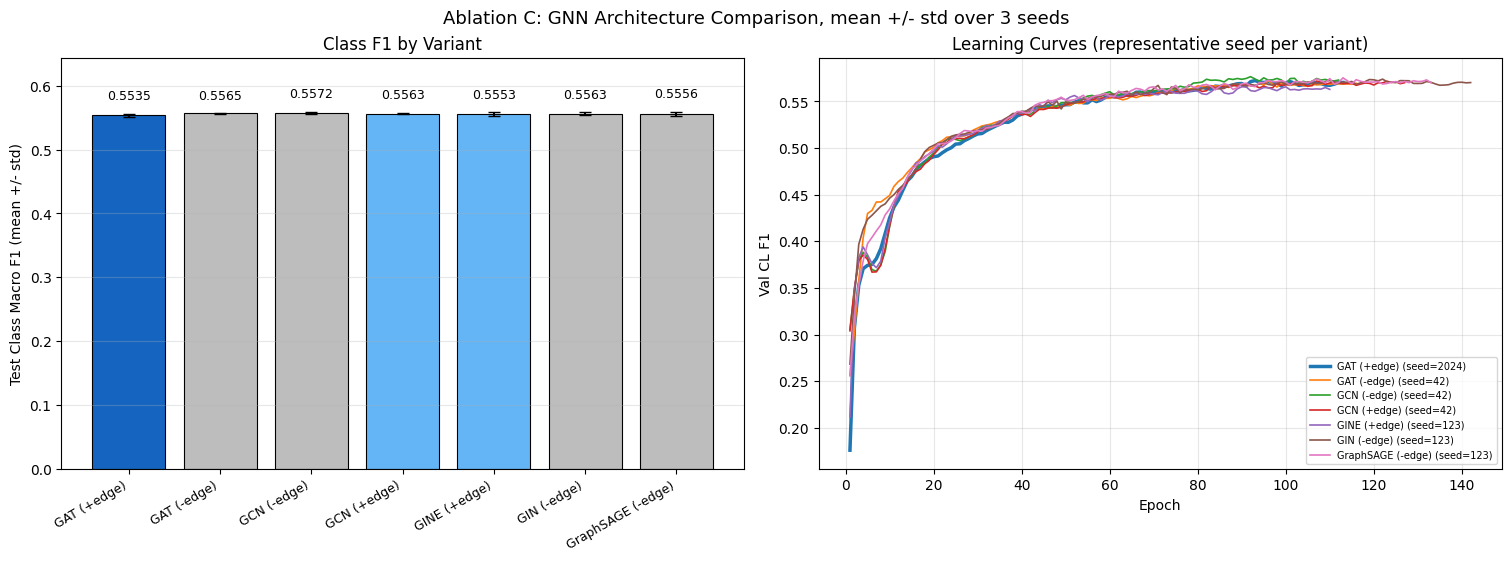

Saved: ablation_c_results.csv  ablation_c_results_by_seed.csv  ablation_c_results.png


In [8]:
arch_variants = {
    'GAT (+edge)':       GATBlock,
    'GAT (-edge)':       GATNoEdgeBlock,
    'GCN (-edge)':       GCNBlock,
    'GCN (+edge)':       GCNEdgeBlock,
    'GINE (+edge)':      GINEdgeBlock,
    'GIN (-edge)':       GINBlock,
    'GraphSAGE (-edge)': SAGEBlock,
}

all_runs        = {}   # arch -> list of per-seed result dicts
summary_results = {}   # arch -> mean/std summary dict

for arch, block_cls in arch_variants.items():
    runs, summary = run_gnn_experiment_multiseed(arch, block_cls, seeds)
    all_runs[arch]        = runs
    summary_results[arch] = summary

print(f'\nAll architectures trained across {len(seeds)} seeds each.')

# ---- Per-seed long-format table (full transparency, one row per (arch, seed)) ----
import pandas as pd
long_rows = []
for arch, runs in all_runs.items():
    for r in runs:
        long_rows.append({
            'Architecture': arch, 'Seed': r['seed'],
            'Val SC F1': r['val_sc_f1'], 'Val CL F1': r['val_cl_f1'],
            'Test SC Acc': r['sc_acc'], 'Test SC F1': r['sc_f1'],
            'Test CL Acc': r['cl_acc'], 'Test CL F1': r['cl_f1'],
            'Best Epoch': r['best_ep'],
        })
df_long = pd.DataFrame(long_rows)
df_long.to_csv(os.path.join(RESULTS_DIR, 'ablation_c_results_by_seed.csv'), index=False)

# ---- Summary table: mean +/- std over seeds ----
rows = []
for arch, s in summary_results.items():
    rows.append({
        'Architecture': arch,
        'Edge feats': '+' if '+edge' in arch else '-',
        'Attention': 'yes' if arch.startswith('GAT') else 'no',
        'Params': s['n_params'],
        'Val CL F1':  f"{s['val_cl_f1_mean']:.4f} +/- {s['val_cl_f1_std']:.4f}",
        'Test SC F1': f"{s['sc_f1_mean']:.4f} +/- {s['sc_f1_std']:.4f}",
        'Test CL F1': f"{s['cl_f1_mean']:.4f} +/- {s['cl_f1_std']:.4f}",
        '_sort': s['cl_f1_mean'],
    })
df = (pd.DataFrame(rows).sort_values('_sort', ascending=False)
        .drop(columns='_sort').reset_index(drop=True))
print(f'\nResults over {len(seeds)} seeds (sorted by mean Test CL F1):')
print(df.to_string(index=False))
df.to_csv(os.path.join(RESULTS_DIR, 'ablation_c_results.csv'), index=False)

# ---- Controlled contrasts using MEAN values, flagged against seed noise ----
def _mean(name): return summary_results[name]['cl_f1_mean']
def _std(name):  return summary_results[name]['cl_f1_std']

def _contrast(label, a, b):
    diff    = _mean(a) - _mean(b)
    noise   = _std(a) + _std(b)   # combined 1-sigma band -- a rough heuristic, not a formal test
    verdict = 'likely real' if abs(diff) > noise else 'within seed noise'
    print(f'  {label:28s}: {a} {_mean(a):.4f}+/-{_std(a):.4f}  vs  {b} {_mean(b):.4f}+/-{_std(b):.4f}'
          f'  ->  diff={diff:+.4f}  ({verdict})')

print(f'\nControlled contrasts (mean Test Class Macro F1 over {len(seeds)} seeds):')
_contrast('edge features (same arch)',     'GAT (+edge)', 'GAT (-edge)')
_contrast('attention vs GCN, no edges',    'GAT (-edge)', 'GCN (-edge)')
_contrast('attention vs GIN, no edges',    'GAT (-edge)', 'GIN (-edge)')
_contrast('attention vs SAGE, no edges',   'GAT (-edge)', 'GraphSAGE (-edge)')
_contrast('attention vs GCN, with edges',  'GAT (+edge)', 'GCN (+edge)')
_contrast('attention vs GINE, with edges', 'GAT (+edge)', 'GINE (+edge)')
print('  Note: "noise" here is a rough heuristic (combined std across the two arms), not a')
print('  formal significance test (e.g. a paired t-test) -- treat "likely real" as suggestive.')

# ---- Plot: bar chart with error bars + one representative learning curve per arch ----
archs = list(summary_results.keys())
means = [summary_results[a]['cl_f1_mean'] for a in archs]
stds  = [summary_results[a]['cl_f1_std']  for a in archs]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
fig.suptitle(f'Ablation C: GNN Architecture Comparison, mean +/- std over {len(seeds)} seeds', fontsize=13)

ax = axes[0]
def _color(a):
    if a == 'GAT (+edge)': return '#1565C0'
    return '#64B5F6' if '+edge' in a else '#BDBDBD'
colors = [_color(a) for a in archs]
bars = ax.bar(range(len(archs)), means, yerr=stds, capsize=4,
              color=colors, edgecolor='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=8, fontsize=9)
ax.set_xticks(range(len(archs))); ax.set_xticklabels(archs, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Test Class Macro F1 (mean +/- std)')
ax.set_title('Class F1 by Variant')
ax.set_ylim(0, max(m + s for m, s in zip(means, stds)) * 1.15)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
for arch, runs in all_runs.items():
    # representative seed: whichever run's val_cl_f1 lands closest to the arch's mean
    med_run = min(runs, key=lambda r: abs(r['val_cl_f1'] - summary_results[arch]['val_cl_f1_mean']))
    curve = med_run['val_cl_f1_curve']
    lw = 2.5 if arch == 'GAT (+edge)' else 1.2
    ax.plot(range(1, len(curve)+1), curve, label=f'{arch} (seed={med_run["seed"]})', linewidth=lw)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val CL F1')
ax.set_title('Learning Curves (representative seed per variant)')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.savefig(os.path.join(RESULTS_DIR, 'ablation_c_results.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ablation_c_results.csv  ablation_c_results_by_seed.csv  ablation_c_results.png')
